In [1]:
import pandas as pd
import numpy as np

# Preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [2]:
train = pd.read_csv("train.csv")
valid = pd.read_csv("valid.csv")
test  = pd.read_csv("test.csv")

In [3]:
train.head()

,ID,Label,Statement,Subject(s),Speaker,Speaker's job title,State,Party,Barely true counts,False counts,Half true counts,Mostly true counts,Pants on fire counts,Context
0,2635.json,FALSE,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,FALSE,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


Label Encoding

In [4]:
def convert_label(label):
    if label in ['false', 'pants-fire', 'barely-true']:
        return 0
    else:
        return 1

train['Label'] = train['Label'].apply(convert_label)
valid['Label'] = valid['Label'].apply(convert_label)
test['Label']  = test['Label'].apply(convert_label)

Text Preprocessing

In [5]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

train['clean_text'] = train['Statement'].apply(preprocess)
valid['clean_text'] = valid['Statement'].apply(preprocess)
test['clean_text']  = test['Statement'].apply(preprocess)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ravindu_pathirana/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


TF-IDF Feature Extraction

In [6]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),   # unigrams + bigrams
    min_df=2,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(train['clean_text'])
X_valid_tfidf = tfidf.transform(valid['clean_text'])
X_test_tfidf  = tfidf.transform(test['clean_text'])

y_train = train['Label']
y_valid = valid['Label']
y_test  = test['Label']

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (10240, 10000)


Chi-Square Feature Selection

In [7]:
k_features = 3000  # you can tune this (2000–5000)

chi2_selector = SelectKBest(score_func=chi2, k=k_features)

X_train_chi2 = chi2_selector.fit_transform(X_train_tfidf, y_train)
X_valid_chi2 = chi2_selector.transform(X_valid_tfidf)
X_test_chi2  = chi2_selector.transform(X_test_tfidf)

print("Chi-square selected shape:", X_train_chi2.shape)

Chi-square selected shape: (10240, 3000)


Mutual Information Feature Selection

In [8]:
mi_selector = SelectKBest(score_func=mutual_info_classif, k=k_features)

X_train_mi = mi_selector.fit_transform(X_train_tfidf, y_train)
X_valid_mi = mi_selector.transform(X_valid_tfidf)
X_test_mi  = mi_selector.transform(X_test_tfidf)

print("Mutual Information selected shape:", X_train_mi.shape)

/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received 

Mutual Information selected shape: (10240, 3000)


/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received 

In [9]:
feature_names = tfidf.get_feature_names_out()

chi2_scores = chi2_selector.scores_

chi2_df = pd.DataFrame({
    'feature': feature_names,
    'chi2_score': chi2_scores
}).sort_values(by='chi2_score', ascending=False)

print("\nTop χ² Features:")
print(chi2_df.head(15))


Top χ² Features:
            feature  chi2_score
5818            rep    8.276783
4565       obamacar    8.105286
4505          obama    7.290344
4132         michel    7.132805
6523     say michel    6.862023
7250      socialist    6.581010
2356   feder reserv    6.137913
2911          group    5.850049
5529           rate    5.663491
3999        marxist    5.448871
8641       transact    5.369576
2659         garden    5.092768
8959          vacat    4.961949
3558  keep unemploy    4.941851
6383    say billion    4.862793


In [10]:
mi_scores = mi_selector.scores_

mi_df = pd.DataFrame({
    'feature': feature_names,
    'mi_score': mi_scores
}).sort_values(by='mi_score', ascending=False)

print("\nTop MI Features:")
print(mi_df.head(15))


Top MI Features:
      feature  mi_score
6356      say  0.145244
7485    state  0.062487
4505    obama  0.055611
9806     year  0.055539
8039      tax  0.050346
4971  percent  0.046311
9072     vote  0.036830
5265   presid  0.036578
3016   health  0.031412
4899    peopl  0.031337
3442      job  0.029708
891      care  0.029449
4163  million  0.029266
9696    would  0.028564
4629      one  0.026277


In [11]:
top_chi2 = set(chi2_df.head(100)['feature'])
top_mi   = set(mi_df.head(100)['feature'])

common_features = top_chi2.intersection(top_mi)

print("Common important features:", len(common_features))

Common important features: 9


Visualization

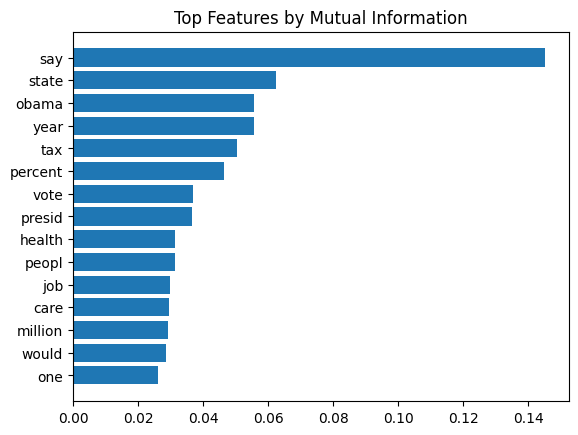

In [12]:
import matplotlib.pyplot as plt

top_features = mi_df.head(15)

plt.barh(top_features['feature'], top_features['mi_score'])
plt.gca().invert_yaxis()
plt.title("Top Features by Mutual Information")
plt.show()

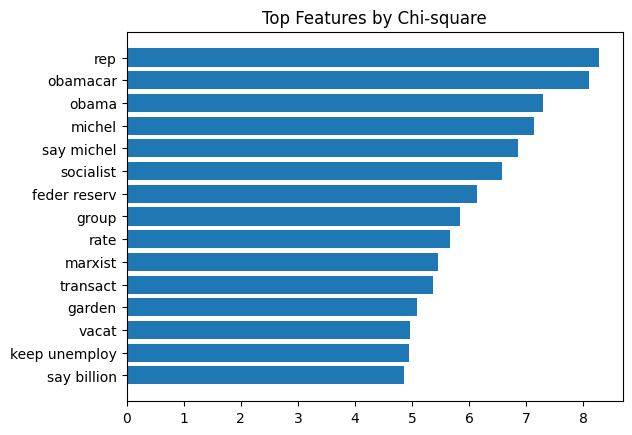

In [13]:
top_features = chi2_df.head(15)

plt.barh(top_features['feature'], top_features['chi2_score'])
plt.gca().invert_yaxis()
plt.title("Top Features by Chi-square")
plt.show()

In [14]:
def evaluate_model(model, X_valid, y_valid, X_test, y_test):
    
    # Validation predictions
    y_valid_pred = model.predict(X_valid)
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    
    results = {
        "valid_accuracy": accuracy_score(y_valid, y_valid_pred),
        "valid_precision": precision_score(y_valid, y_valid_pred),
        "valid_recall": recall_score(y_valid, y_valid_pred),
        "valid_f1": f1_score(y_valid, y_valid_pred),
        
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_precision": precision_score(y_test, y_test_pred),
        "test_recall": recall_score(y_test, y_test_pred),
        "test_f1": f1_score(y_test, y_test_pred),
    }
    
    return results

GridSearch+Evaluation

In [15]:
def train_and_evaluate(model, param_grid, X_train, y_train, X_valid, y_valid, X_test, y_test):
    
    grid = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='f1',   # better than accuracy for imbalance
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    results = evaluate_model(best_model, X_valid, y_valid, X_test, y_test)
    
    return best_model, grid.best_params_, results

LR+GridSearchCV

In [16]:
lr_model = LogisticRegression(max_iter=1000)

lr_params = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

SVM+GridSearchCV

In [17]:
svm_model = LinearSVC()

svm_params = {
    'C': [0.1, 1, 10]
}

NB+GridSearchCV

In [18]:
nb_model = MultinomialNB()

nb_params = {
    'alpha': [0.1, 0.5, 1.0]
}

RF+GridSearchCV

In [19]:
rf_model = RandomForestClassifier()

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

XGB+GridSearchCV

In [20]:
xgb_model = XGBClassifier(eval_metric='logloss', use_label_encoder=False)

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1]
}

 RUN EXPERIMENTS (χ² FEATURES)

In [21]:
results_chi2 = {}

models = [
    ("Logistic Regression", lr_model, lr_params),
    ("SVM", svm_model, svm_params),
    ("Naive Bayes", nb_model, nb_params),
    ("Random Forest", rf_model, rf_params),
    ("XGBoost", xgb_model, xgb_params)
]

for name, model, params in models:
    print(f"\nTraining {name} with Chi-square features...")
    
    best_model, best_params, results = train_and_evaluate(
        model, params,
        X_train_chi2, y_train,
        X_valid_chi2, y_valid,
        X_test_chi2, y_test
    )
    
    results_chi2[name] = {
        "best_params": best_params,
        "metrics": results
    }


Training Logistic Regression with Chi-square features...

Training SVM with Chi-square features...

Training Naive Bayes with Chi-square features...

Training Random Forest with Chi-square features...

Training XGBoost with Chi-square features...


/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [23:14:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [23:14:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [23:14:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [23:14:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_e

 RUN EXPERIMENTS (MI FEATURES)

In [22]:
results_mi = {}

for name, model, params in models:
    print(f"\nTraining {name} with MI features...")
    
    best_model, best_params, results = train_and_evaluate(
        model, params,
        X_train_mi, y_train,
        X_valid_mi, y_valid,
        X_test_mi, y_test
    )
    
    results_mi[name] = {
        "best_params": best_params,
        "metrics": results
    }


Training Logistic Regression with MI features...

Training SVM with MI features...

Training Naive Bayes with MI features...

Training Random Forest with MI features...

Training XGBoost with MI features...


/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [23:14:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [23:14:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [23:14:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [23:14:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_e

results to table

In [23]:
def results_to_dataframe(results_dict, method_name):
    rows = []
    
    for model_name, data in results_dict.items():
        metrics = data['metrics']
        
        row = {
            "Method": method_name,
            "Model": model_name,
            "Valid Accuracy": metrics['valid_accuracy'],
            "Valid Precision": metrics['valid_precision'],
            "Valid Recall": metrics['valid_recall'],
            "Valid F1": metrics['valid_f1'],
            "Test Accuracy": metrics['test_accuracy'],
            "Test Precision": metrics['test_precision'],
            "Test Recall": metrics['test_recall'],
            "Test F1": metrics['test_f1'],
        }
        
        rows.append(row)
    
    return pd.DataFrame(rows)


In [24]:
df_chi2 = results_to_dataframe(results_chi2, "Chi-square")
df_mi   = results_to_dataframe(results_mi, "Mutual Information")

final_results = pd.concat([df_chi2, df_mi])

print(final_results)

               Method                Model  Valid Accuracy  Valid Precision  \
0          Chi-square  Logistic Regression        0.705607         0.740226   
1          Chi-square                  SVM        0.713396         0.742463   
2          Chi-square          Naive Bayes        0.725078         0.737274   
3          Chi-square        Random Forest        0.725078         0.725078   
4          Chi-square              XGBoost        0.726636         0.726562   
0  Mutual Information  Logistic Regression        0.725078         0.725078   
1  Mutual Information                  SVM        0.722741         0.727633   
2  Mutual Information          Naive Bayes        0.725857         0.728854   
3  Mutual Information        Random Forest        0.725078         0.725078   
4  Mutual Information              XGBoost        0.723520         0.725000   

   Valid Recall  Valid F1  Test Accuracy  Test Precision  Test Recall  \
0      0.915145  0.818444       0.734017        0.773601 

In [25]:
final_results.to_csv("model_comparison_results.csv", index=False)

In [26]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Now choose the best parameters of XGB

In [27]:
best_model, best_params, results = train_and_evaluate(
        xgb_model, xgb_params,
        X_train_chi2, y_train,
        X_valid_chi2, y_valid,
        X_test_chi2, y_test
    )

/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [23:14:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [23:14:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [23:14:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [23:14:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_e

Apply Shap

In [28]:
import shap
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test_chi2)

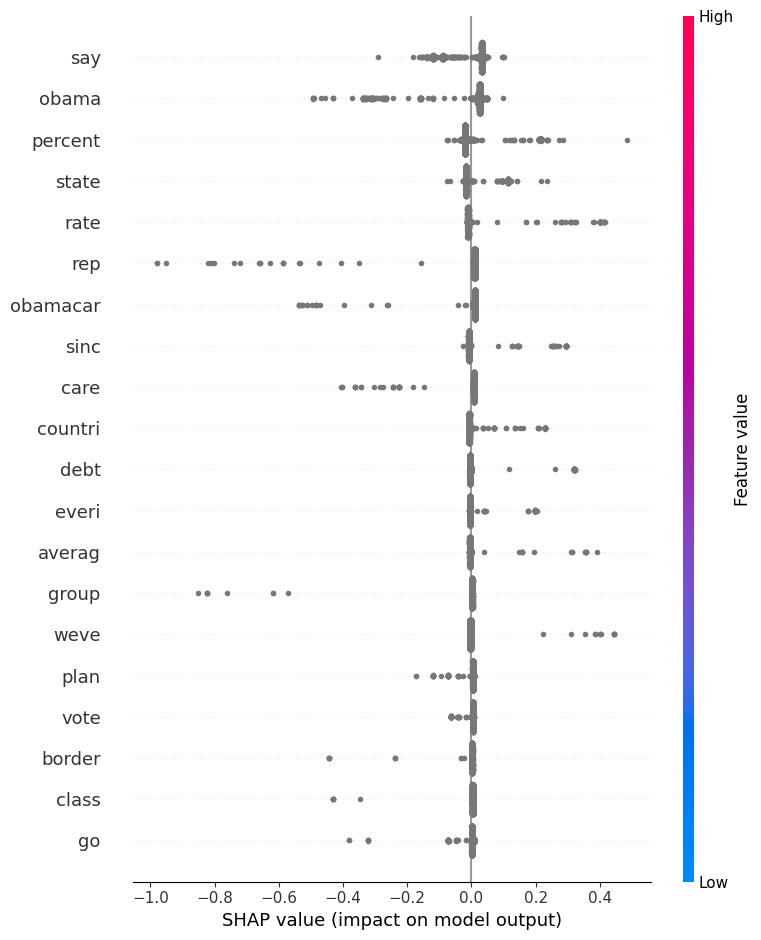

In [29]:
import matplotlib.pyplot as plt

feature_names = tfidf.get_feature_names_out()
selected_features = feature_names[chi2_selector.get_support()]

# Plot
shap.summary_plot(
    shap_values,
    X_test_chi2,
    feature_names=selected_features
)

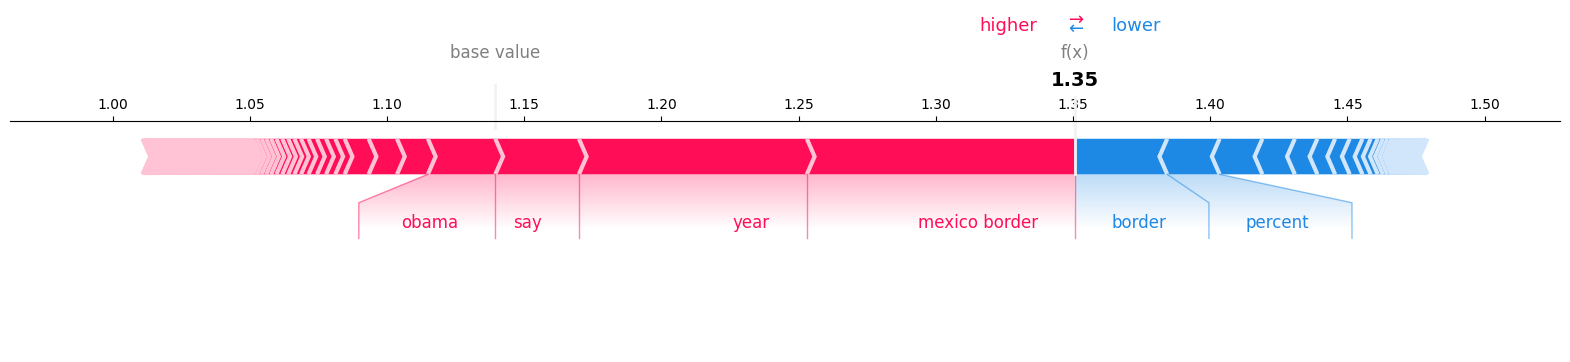

In [30]:
# Explain one sample
index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    feature_names=selected_features,
    matplotlib=True
)

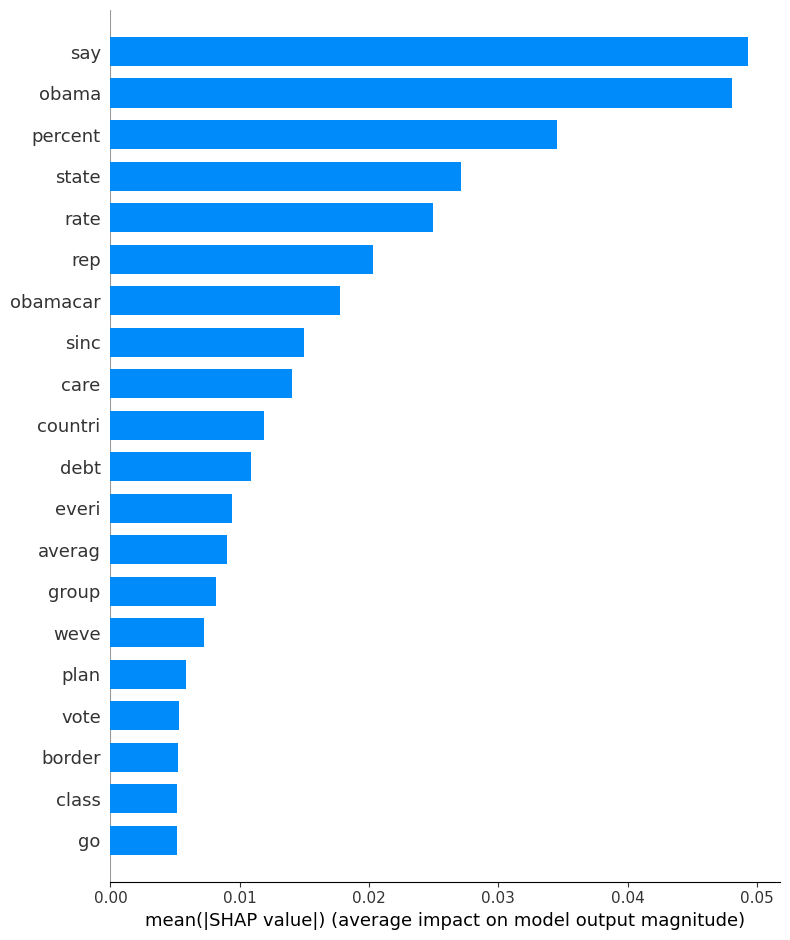

In [31]:
shap.summary_plot(
    shap_values,
    X_test_chi2,
    feature_names=selected_features,
    plot_type="bar"
)